# $\text{Eksperimen untuk Tautan Hopf}$

/tmp/ipykernel_1843/3652835900.py:78: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  IQFT = QFT(


========== Betti Number Estimation ==========
Kombinasi: [4, 4, 5]
Trace Gibbs: 4.183705543351274
Probabilitas: 0.9561401007976744
Betti global: 4.000208639927676
Error: 0.00020863992767594652


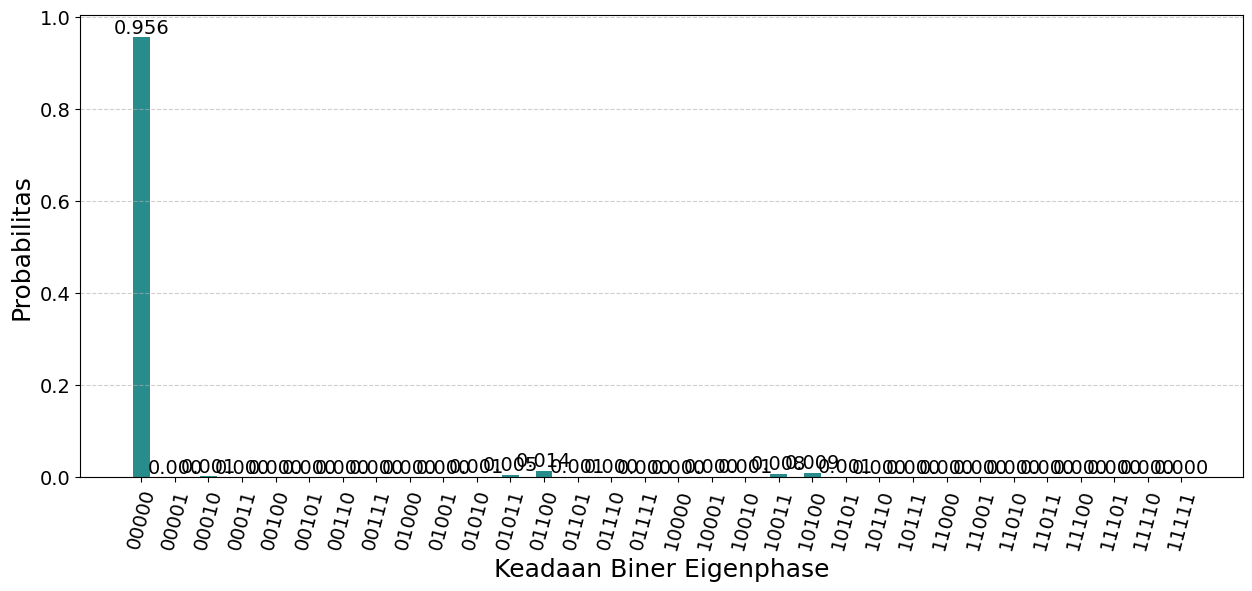

In [ ]:
# ==========================
# Identity Padding Function
# ==========================
import numpy as np

def identity_padding(matrix):
    # Dimensi awal matriks
    n = matrix.shape[0]

    # Mencari pangkat dua terdekat
    N = 2**(int(np.ceil(np.log2(n))))

    # Jika matriks sudah 2^n x 2^n
    pad = N - n
    if pad == 0:
        return matrix

    # Matriks 0 berukuran N x N
    matrix_padding = np.zeros((N, N))

    # Blok utama diisi dengan matriks utama
    matrix_padding[:n, :n] = matrix

    # Identity padding untuk blok sisa
    matrix_padding[n:, n:] = np.eye(pad)

    return matrix_padding

# =====================
# Gibbs State Function
# =====================
import numpy as np
from scipy.linalg import expm

def gibbs_state(matrix, mu):
    exp_matrix = expm(-mu * matrix)
    return exp_matrix / np.trace(exp_matrix)

# =====================
# Trace of Gibbs State
# =====================
def trace(matrix, mu):
    exp_matrix = expm(-mu * matrix)
    return np.trace(exp_matrix)

# ==========================
# Unitary Operator Function
# ==========================
from scipy.linalg import expm

def unitary_operator(matrix, time):
    return expm(-1j * matrix * time)

# ===============================
# Quantum Phase Estimation (QPE)
# ===============================
from qiskit.circuit.library import UnitaryGate, QFT

def QuantumPhaseEstimation(quantum_circuit, unitary_matrix, n_control):
    # Menentukan total qubit
    U_gate = UnitaryGate(unitary_matrix.data)
    n_target = U_gate.num_qubits
    total_qubit = n_control + n_target

    # Hadamard untuk qubit kontrol
    for i in range(n_control):
        quantum_circuit.h(i)

    # Menerapkan iterasi Controlled-U^(2^(k))
    target_qubits = list(range(n_control, total_qubit))
    for k in range(n_control):
        controlled_U = U_gate.power(2**k).control(1)
        quantum_circuit.append(controlled_U, [k] + target_qubits)

    # Menerapkan IQFT bawaan Qiskit
    quantum_circuit.barrier()

    IQFT = QFT(
        num_qubits=n_control,
        inverse=True
    )

    quantum_circuit.append(IQFT, range(n_control))

# ===========================
# Matriks Khovanov Laplacian
# ===========================
import numpy as np
from scipy.linalg import block_diag

# Matriks diferensial d^0
d0 = np.array([
    [1, 0, 0, 0],
    [0, 1, 1, 0],
    [1, 0, 0, 0],
    [0, 1, 1, 0],
    [1, 0, 0, 0],
    [0, 1, 1, 0]
], dtype=float)

# Matriks diferensial d^1
d1 = np.array([
    [0, 0, 0, 0, 0, 0],
    [1, 0, -1, 0, 0, 0],
    [1, 0, -1, 0, 0, 0],
    [0, 1, 0, -1, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, -1, 0],
    [1, 0, 0, 0, -1, 0],
    [0, 1, 0, 0, 0, -1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, -1, 0],
    [0, 0, 1, 0, -1, 0],
    [0, 0, 0, 1, 0, -1]
], dtype=float)

# Matriks diferensial d^2
d2 = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0],
    [1, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, -1, 0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 1]
], dtype=float)

# Khovanov Laplacian ke-0
Delta0 = d0.conj().T @ d0

# Khovanov Laplacian ke-1
Delta1 = d1.conj().T @ d1 + d0 @ d0.conj().T

# Khovanov Laplacian ke-2
Delta2 = d2.conj().T @ d2 + d1 @ d1.conj().T

# Khovanov Laplacian ke-3
Delta3 = d2 @ d2.conj().T

# Jumlah langsung semua Laplacian (Laplacian global)
Delta = block_diag(Delta0, Delta1, Delta2, Delta3)

# =================
# Simulasi Kuantum
# =================
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix
from qiskit import QuantumCircuit, transpile

# Bantalan identitas untuk Laplacian global
Delta_pad = identity_padding(Delta)

# Variasi Parameter
X = [4, 4, 5]

# Membentuk keadaan Gibbs
mu = X[0]
keadaan_gibbs = gibbs_state(Delta_pad, mu)

# Membantuk operator uniter
t = X[1]
operator_uniter = unitary_operator(Delta_pad, t)

# Inisialisasi
qubit_resolusi = X[2]
qubit_sistem = int(np.log2(Delta_pad.shape[0]))
total_qubits = qubit_resolusi + qubit_sistem

# Matriks densitas untuk qubit resolusi
rho_resolusi = np.zeros((2**qubit_resolusi, 2**qubit_resolusi), dtype=complex)
rho_resolusi[0,0] = 1

# Matriks densitas untuk qubit total
rho_total = np.kron(keadaan_gibbs, rho_resolusi)
rho = DensityMatrix(rho_total)

# Sirkuit kuantum berbasis matriks densitas
qc = QuantumCircuit(total_qubits)
qc.set_density_matrix(rho)

# Menerapkan Quantum Phase Estimation
QuantumPhaseEstimation(qc, operator_uniter, qubit_resolusi)
qc.save_density_matrix()

# Simulasi
sim = AerSimulator(method="density_matrix")
qct = transpile(qc, sim)
result = sim.run(qct).result()
final_rho = result.data(0)['density_matrix']

# ========================
# Estimasi Bilangan Betti
# ========================
import numpy as np
from qiskit.quantum_info import DensityMatrix, partial_trace

# Partial trace
rho_total = DensityMatrix(final_rho)
rho_phase = partial_trace(rho_total, list(np.arange(qubit_resolusi, total_qubits)))

# Perhitungan bilangan Betti
chain_dimension = trace(Delta_pad, mu)
probabilities = np.real(np.diag(rho_phase.data))
probability_zero = probabilities[0]
kernel_dimension = chain_dimension * probability_zero

print("========== Betti Number Estimation ==========")
print(f"Kombinasi: {X}")
print(f'Trace Gibbs: {chain_dimension}')
print(f"Probabilitas: {probability_zero}")
print(f"Betti global: {kernel_dimension}")
print(f"Error: {kernel_dimension - 4}")

# ======================
# Bar Plot Probabilitas
# ======================
import matplotlib.pyplot as plt

bitstrings = []
probability = []
for i, p in enumerate(probabilities):
    bitstrings.append(format(i, f'0{qubit_resolusi}b'))
    probability.append(p)

# Plotting
plt.figure(figsize=(15, 6))
bars = plt.bar(bitstrings, probability, width=0.5, color='#298c8c')

plt.xlabel("Keadaan Biner Eigenphase", fontsize=18)
plt.ylabel("Probabilitas", fontsize=18)

plt.xticks(rotation=75, fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.6)

# Menampilkan angka probabilitas di atas bar
for bar, prob in zip(bars, probability):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        prob,
        f"{prob:.3f}",
        ha='center',
        va='bottom',
        fontsize=14
    )

plt.savefig('distribusi_probabilitas_trefoil.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# from google.colab import files

# files.download('distribusi_probabilitas_hopf.png')

# $\text{Uji - Uji pada Matriks}$

#### $\text{Uji Hermitian}$ $\texttt{Delta_pad}$

In [ ]:
np.allclose(Delta_pad, Delta_pad.conj().T)

True

In [ ]:
eigenvalue1, _ = np.linalg.eigh(Delta_pad)
print(eigenvalue1)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.83133613e-16
 6.12422578e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.46418946e+00 1.46791111e+00
 2.45647949e+00 2.65270364e+00 3.00000000e+00 3.00000000e+00
 3.00000000e+00 3.00000000e+00 3.00000000e+00 3.00000000e+00
 3.00000000e+00 3.00000000e+00 3.72407902e+00 4.00000000e+00
 4.72446005e+00 4.87938524e+00 6.00000000e+00 6.00000000e+00
 6.00000000e+00 6.00000000e+00 6.00000000e+00 7.01836940e+00]


#### $\text{Uji Matriks Densitas}$ $\texttt{keadaan_gibbs}$

In [ ]:
np.allclose(keadaan_gibbs, keadaan_gibbs.conj().T)

True

In [ ]:
eigenvalue2, _ = np.linalg.eigh(keadaan_gibbs)
print(eigenvalue2)

[0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.03125
 0.03125 0.03125 0.03125 0.03125 0.03125]


In [ ]:
np.trace(keadaan_gibbs)

np.float64(1.0)

#### $\text{Uji Operator Uniter}$ $\texttt{operator_uniter}$

In [ ]:
np.allclose(operator_uniter @ operator_uniter.conj().T, np.eye(operator_uniter.shape[0]))

True

# $\text{Analisis Data Simulasi}$

In [ ]:
import numpy as np

# ==========================================
# Fungsi simulasi untuk satu parameter X
# ==========================================
def estimasi_betti(mu, t, qubit_resolusi):
    # Bantalan identitas untuk Laplacian global
    Delta_pad = identity_padding(Delta)

    # Membentuk keadaan Gibbs
    keadaan_gibbs = gibbs_state(Delta_pad, mu)

    # Membentuk operator uniter
    operator_uniter = unitary_operator(Delta_pad, t)

    # Inisialisasi qubit
    qubit_sistem = int(np.log2(Delta_pad.shape[0]))
    total_qubits = qubit_resolusi + qubit_sistem

    # Matriks densitas untuk qubit resolusi
    rho_resolusi = np.zeros(
        (2**qubit_resolusi, 2**qubit_resolusi),
        dtype=complex
    )
    rho_resolusi[0, 0] = 1

    # Matriks densitas total
    rho_total = np.kron(keadaan_gibbs, rho_resolusi)
    rho = DensityMatrix(rho_total)

    # Sirkuit kuantum
    qc = QuantumCircuit(total_qubits)
    qc.set_density_matrix(rho)

    # Quantum Phase Estimation
    QuantumPhaseEstimation(qc, operator_uniter, qubit_resolusi)
    qc.save_density_matrix()

    # Simulasi
    sim = AerSimulator(method="density_matrix")
    qct = transpile(qc, sim)
    result = sim.run(qct).result()
    final_rho = result.data(0)['density_matrix']

    # Estimasi bilangan Betti
    rho_total = DensityMatrix(final_rho)
    rho_phase = partial_trace(
        rho_total,
        list(np.arange(qubit_resolusi, total_qubits))
    )
    chain_dimension = trace(Delta_pad, mu)
    probabilities = np.real(np.diag(rho_phase.data))
    probability_zero = probabilities[0]
    kernel_dimension = chain_dimension * probability_zero
    error = kernel_dimension - 4

    return {
        "mu": mu,
        "t": t,
        "k": qubit_resolusi,
        "trace_gibbs": chain_dimension,
        "probabilitas": probability_zero,
        "betti_global": kernel_dimension,
        "error": error
    }

# ==========================================
# Variasi parameter FLFD Tereduksi
# ==========================================
data = [
    [0, 2, 3],
    [1, 2, 3],
    [2, 2, 3],
    [3, 2, 3],
    [4, 2, 3],

    [2, 0, 3],
    [2, 1, 3],
    [2, 2, 3],
    [2, 3, 3],
    [2, 4, 3],

    [2, 2, 1],
    [2, 2, 2],
    [2, 2, 3],
    [2, 2, 4],
    [2, 2, 5],

    [0, 0, 3],
    [1, 1, 3],
    [2, 2, 3],
    [3, 3, 3],
    [4, 4, 3],

    [0, 2, 1],
    [1, 2, 2],
    [2, 2, 3],
    [3, 2, 4],
    [4, 2, 5],

    [2, 0, 1],
    [2, 1, 2],
    [2, 2, 3],
    [2, 3, 4],
    [2, 4, 5],

    [0, 0, 1],
    [1, 1, 2],
    [2, 2, 3],
    [3, 3, 4],
    [4, 4, 5]
]

data_simulasi = []
for order, value in enumerate(data):
    print(f"Running: mu={value[0]}, t={value[1]}, k={value[2]} ===> {order + 1}/{len(data)}")
    out = estimasi_betti(value[0], value[1], value[2])
    data_simulasi.append(out)

Running: mu=0, t=2, k=3 ===> 1/35


/tmp/ipykernel_9787/1838772973.py:78: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  IQFT = QFT(


Running: mu=1, t=2, k=3 ===> 2/35
Running: mu=2, t=2, k=3 ===> 3/35
Running: mu=3, t=2, k=3 ===> 4/35
Running: mu=4, t=2, k=3 ===> 5/35
Running: mu=2, t=0, k=3 ===> 6/35
Running: mu=2, t=1, k=3 ===> 7/35
Running: mu=2, t=2, k=3 ===> 8/35
Running: mu=2, t=3, k=3 ===> 9/35
Running: mu=2, t=4, k=3 ===> 10/35
Running: mu=2, t=2, k=1 ===> 11/35
Running: mu=2, t=2, k=2 ===> 12/35
Running: mu=2, t=2, k=3 ===> 13/35
Running: mu=2, t=2, k=4 ===> 14/35
Running: mu=2, t=2, k=5 ===> 15/35
Running: mu=0, t=0, k=3 ===> 16/35
Running: mu=1, t=1, k=3 ===> 17/35
Running: mu=2, t=2, k=3 ===> 18/35
Running: mu=3, t=3, k=3 ===> 19/35
Running: mu=4, t=4, k=3 ===> 20/35
Running: mu=0, t=2, k=1 ===> 21/35
Running: mu=1, t=2, k=2 ===> 22/35
Running: mu=2, t=2, k=3 ===> 23/35
Running: mu=3, t=2, k=4 ===> 24/35
Running: mu=4, t=2, k=5 ===> 25/35
Running: mu=2, t=0, k=1 ===> 26/35
Running: mu=2, t=1, k=2 ===> 27/35
Running: mu=2, t=2, k=3 ===> 28/35
Running: mu=2, t=3, k=4 ===> 29/35
Running: mu=2, t=4, k=5 ===>

In [ ]:
import pandas as pd

data_analisis = pd.DataFrame(data_simulasi)
data_analisis

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
0,0,2,3,32.000000,0.313874,10.043983,6.043983
1,1,2,3,7.469815,0.579921,4.331902,0.331902
2,2,2,3,5.110282,0.790969,4.042073,0.042073
3,3,2,3,4.434777,0.905011,4.013522,0.013522
4,4,2,3,4.183706,0.957525,4.006002,0.006002
5,2,0,3,5.110282,1.000000,5.110282,1.110282
6,2,1,3,5.110282,0.792076,4.047732,0.047732
7,2,2,3,5.110282,0.790969,4.042073,0.042073
8,2,3,3,5.110282,0.785024,4.011694,0.011694
9,2,4,3,5.110282,0.791051,4.042495,0.042495


In [ ]:
hasil_spesifik = data_analisis[
    (data_analisis['mu'] == 4) &
    (data_analisis['t'] == 2) &
    (data_analisis['k'] == 3)
]

hasil_spesifik

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
4,4,2,3,4.183706,0.957525,4.006002,0.006002


#### $\text{Analisis Deskriptif}$

In [ ]:
data_analisis.describe()

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2.000000,2.000000,3.000000,8.269958,0.810194,6.427835,2.427835
std,1.084652,1.084652,1.084652,8.694712,0.146564,7.101560,7.101560
min,0.000000,0.000000,1.000000,4.183706,0.313874,4.000159,0.000159
25%,2.000000,2.000000,3.000000,5.110282,0.783464,4.004260,0.004260
50%,2.000000,2.000000,3.000000,5.110282,0.790969,4.042073,0.042073
75%,2.000000,2.000000,3.000000,5.110282,0.904019,4.378120,0.378120
max,4.000000,4.000000,5.000000,32.000000,1.000000,32.000000,28.000000


Data sudah seimbang dengan semua feature memiliki 35 sample

In [ ]:
data_analisis[data_analisis["error"] <= 0.001]

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
23,3,2,4,4.434777,0.902095,4.000588,0.000588
24,4,2,5,4.183706,0.956128,4.000159,0.000159
34,4,4,5,4.183706,0.956140,4.000209,0.000209


Nilai $\mu$ tertinggi dan nilai $k$ tertinggi menghasilkan estimasi bilangan Betti paling akurat

In [ ]:
data_analisis.groupby("mu")["error"].mean()

,error
mu,
0,19.931734
1,0.439246
2,0.182166
3,0.005100
4,0.002188


Secara kasar, semakin tinggi nilai $\mu$, maka error estimasi bilangan Betti $E$ akan semakin kecil

In [ ]:
data_analisis.groupby("t")["error"].mean()

,error
t,
0,14.555141
1,0.318898
2,1.337352
3,0.005445
4,0.011650


Secara kasar, semaking tinggi nilai $t$, maka error estimasi bilangan Betti $E$ akan semakin kecil

In [ ]:
data_analisis.groupby("k")["error"].mean()

,error
k,
1,11.804237
2,0.427837
3,1.896464
4,0.002399
5,0.000878


Secara kasar, semakin tinggi nilai $k$, maka error estimasi bilangan Betti $E$ akan semakin kecil

#### $\text{Model Regresi Kuadratik}$

In [ ]:
import statsmodels.api as sm

# Data eksperimen
X = data_analisis[["mu", "t", "k"]]

# Fitur kuadratik dan interaksi
X["mu2"] = X["mu"]**2
X["t2"] = X["t"]**2
X["k2"] = X["k"]**2
X["mu_t"] = X["mu"] * X["t"]
X["mu_k"] = X["mu"] * X["k"]
X["t_k"] = X["t"] * X["k"]

X = sm.add_constant(X)
y = data_analisis["error"]

# Menerapkan Ordinary Least Squares
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  error   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     12.73
Date:                Sat, 23 May 2026   Prob (F-statistic):           2.58e-07
Time:                        14:54:58   Log-Likelihood:                -87.674
No. Observations:                  35   AIC:                             195.3
Df Residuals:                      25   BIC:                             210.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.5919      3.831      6.681      0.0

/tmp/ipykernel_9787/2366042014.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["mu2"] = X["mu"]**2
/tmp/ipykernel_9787/2366042014.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["t2"] = X["t"]**2
/tmp/ipykernel_9787/2366042014.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-

#### $\text{Uji Normalitas Residual}$

In [ ]:
# Data residual dan nilai fit
residual = model.resid
fitted = model.fittedvalues

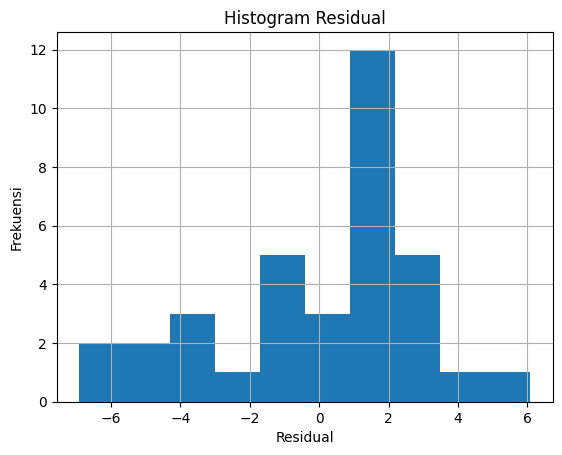

In [ ]:
# A. Histogram Residual
import matplotlib.pyplot as plt

plt.hist(residual, bins=10)
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.title("Histogram Residual")
plt.grid()
plt.show()

Secara kasar, distribusi residual berbentuk lonceng, maka dapat diidentifikasi sebagai **distribusi normal**

In [ ]:
# B. Uji Shapiro-Wilk
from scipy.stats import shapiro

stat, p = shapiro(residual)
print("p-value:", p)

p-value: 0.09469122562253968


Residual dapat diidentifikasi sebagai **distribusi normal** karena $p > 0{,}05$ pada Uji Shapiro - Wilk

In [ ]:
# C. Uji Kolmogorov-Simirnov
from scipy.stats import kstest
import numpy as np

ks = kstest(residual, 'norm', args=(np.mean(residual), np.std(residual)))
print(f"p-value: {ks[1]}")

p-value: 0.19406511989985176


Residual dapat diidentifikasi sebagai **distribusi normal** karena $p > 0{,}05$ pada Uji Kolmogorov - Simirov

#### $\text{Uji Homoskedastisitas}$

In [ ]:
# Uji White Test
from statsmodels.stats.diagnostic import het_white

test = het_white(residual, X)
labels = ['LM Stat', 'LM p-value', 'F Stat', 'F p-value']
white = dict(zip(labels, test))
print(F"P-value: {white["LM p-value"]}")

P-value: 0.1106930463003101


Residual dapat diidentifikasi bersifat **homoskedastisitas** karena $p > 0{,}05$ pada Uji White

# $\text{Visualisasi Permukaan Respons}$

#### $\text{Suhu Invers $\mu$ vs Waktu Evolusi $t$}$

In [ ]:
import numpy as np
import plotly.graph_objects as go

mu_range = np.linspace(0, 4, 100)
t_range = np.linspace(0, 4, 100)

MU, T = np.meshgrid(mu_range, t_range)
K = 3 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=T,
        z=ERROR,
        colorscale='Viridis',
        colorbar=dict(
                title='Error',
                x=0.6,         # kecil == dekat ke plot
                len=0.45,      # panjang colorbar
                thickness=16   # ketebalan
            )
    )
])

fig.update_layout(
    title=f"Surface Plot: mu vs t (k={K})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="t",
        zaxis_title="Error"
    )
)

fig.show()

<>:28: SyntaxWarning:

invalid escape sequence '\m'

<>:28: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_9787/3749736131.py:28: SyntaxWarning:

invalid escape sequence '\m'



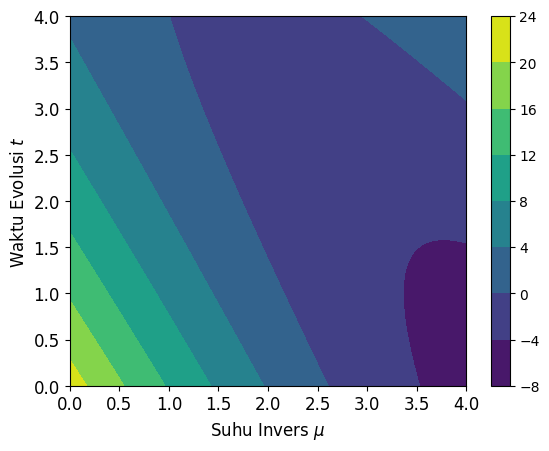

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_range = np.linspace(0, 4, 100)
t_range = np.linspace(0, 4, 100)

MU, T = np.meshgrid(mu_range, t_range)
K = 3 # Fixed point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(MU, T, ERROR)
plt.colorbar(cp)
plt.xlabel("Suhu Invers $\mu$", fontsize=12)
plt.ylabel("Waktu Evolusi $t$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig("trefoil_contour_mu_t.png", dpi=300, bbox_inches='tight')
plt.show()

#### $\text{Suhu Invers $\mu$ vs Jumlah Qubit Resolusi $k$}$

In [ ]:
mu_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

MU, K = np.meshgrid(mu_range, k_range)
T = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.6,         # kecil == dekat ke plot
                len=0.45,      # panjang colorbar
                thickness=16   # ketebalan
            ) )
])

fig.update_layout(
    title=f"Surface Plot: mu vs k (t={T})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

<>:25: SyntaxWarning:

invalid escape sequence '\m'

<>:25: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_9787/4247671693.py:25: SyntaxWarning:

invalid escape sequence '\m'



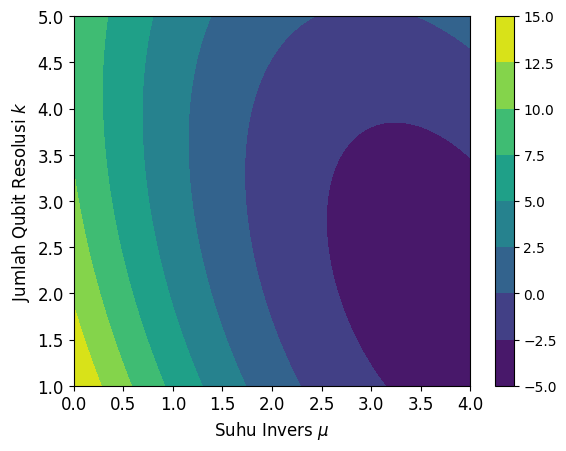

In [ ]:
mu_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

MU, K = np.meshgrid(mu_range, k_range)
T = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(MU, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Suhu Invers $\mu$", fontsize=12)
plt.ylabel("Jumlah Qubit Resolusi $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig("trefoil_contour_mu_k.png", dpi=300, bbox_inches='tight')
plt.show()

#### $\text{Waktu Evolusi $t$ vs Jumlah Qubit Resolusi $k$}$

In [ ]:
t_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

T, K = np.meshgrid(t_range, k_range)
MU = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=T,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.55,
                len=0.45,
                thickness=16
            ) )
])

fig.update_layout(
    title=f"Surface Plot: t vs k (mu={MU})",
    scene=dict(
        xaxis_title="t",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

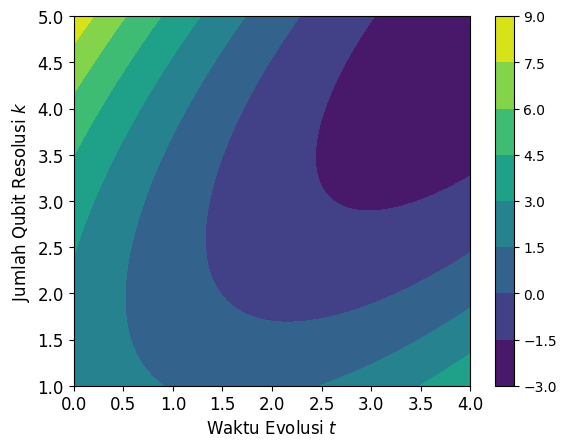

In [ ]:
t_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

T, K = np.meshgrid(t_range, k_range)
MU = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(T, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Waktu Evolusi $t$", fontsize=12)
plt.ylabel("Jumlah Qubit Resolusi $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig("trefoil_contour_t_k.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

# files.download('trefoil_contour_mu_t.png')
# files.download('trefoil_contour_mu_k.png')
files.download('distribusi_probabilitas_trefoil.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>